# GP — AI-Based Adaptive Cybersecurity Governance in Supply Chains
### Rennes School of Business | Student: Palakurthy Naga Shivani | 2025–2026

---

## Step 1: Data Preprocessing

**Dataset:** UNSW-NB15 (82,332 records, 45 features)  
**What this notebook does:**
1. Loads and explores the UNSW-NB15 dataset
2. Encodes categorical features
3. Normalizes numeric features
4. Splits into 80% train / 20% test
5. Saves processed files for model training




In [6]:
import subprocess
packages = ["pandas", "numpy", "scikit-learn", "xgboost", 
            "shap", "lime", "matplotlib", "seaborn", "imbalanced-learn"]
for pkg in packages:
    subprocess.run(["pip", "install", pkg, "-q"], capture_output=True)
print("All libraries ready!")


✅ All libraries ready!


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Plot settings
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")

print("Imports successful")


Imports successful


---
### 1. Load the Dataset

In [19]:
# ── UPDATE THIS PATH if your CSV is in a different folder ──
RANDOM_STATE = 42
TEST_SIZE = 0.20

df = pd.read_csv("UNSW_NB15_testing-set.csv")
print(f"Dataset loaded")
print(f"   Rows     : {df.shape[0]:,}")
print(f"   Columns  : {df.shape[1]}")
df.head()


Dataset loaded
   Rows     : 82,332
   Columns  : 45


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


---
###  2. Data Exploration

In [21]:
print("── Column Info ──")
print(df.dtypes)
print(f"\nMissing values : {df.isnull().sum().sum()}")
print(f"Duplicate rows : {df.duplicated().sum()}")


── Column Info ──
id                     int64
dur                  float64
proto                 object
service               object
state                 object
spkts                  int64
dpkts                  int64
sbytes                 int64
dbytes                 int64
rate                 float64
sttl                   int64
dttl                   int64
sload                float64
dload                float64
sloss                  int64
dloss                  int64
sinpkt               float64
dinpkt               float64
sjit                 float64
djit                 float64
swin                   int64
stcpb                  int64
dtcpb                  int64
dwin                   int64
tcprtt               float64
synack               float64
ackdat               float64
smean                  int64
dmean                  int64
trans_depth            int64
response_body_len      int64
ct_srv_src             int64
ct_state_ttl           int64
ct_dst_ltm             in

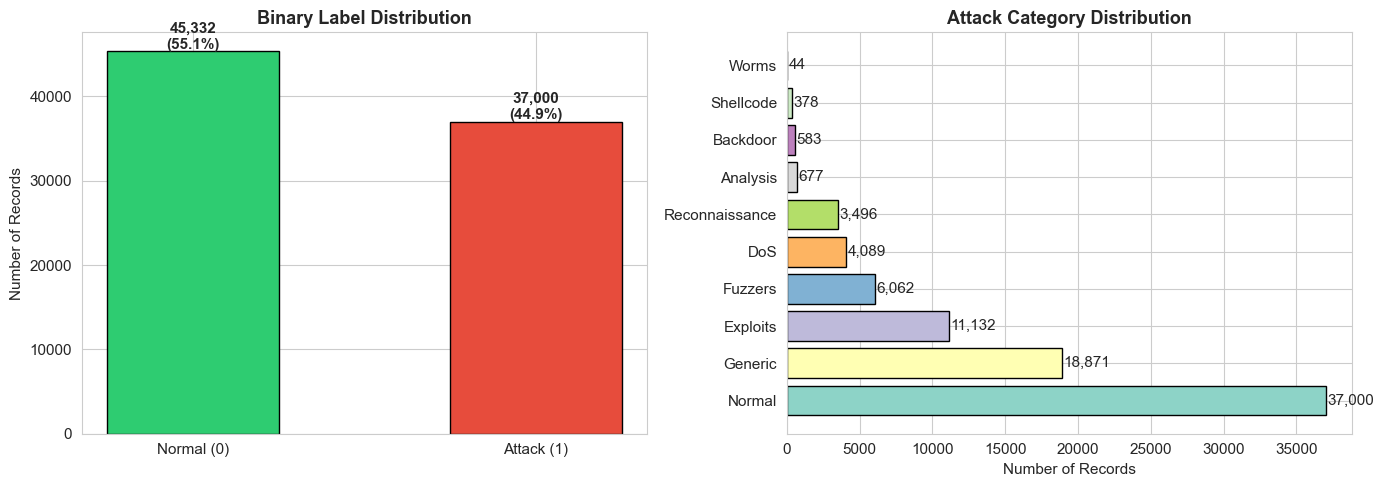

✅ Saved: fig1_label_distribution.png


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Binary label
label_counts = df['label'].value_counts()
axes[0].bar(['Normal (0)', 'Attack (1)'], label_counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.5)
axes[0].set_title('Binary Label Distribution', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Number of Records')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 300, f'{v:,}\n({v/len(df)*100:.1f}%)', 
                 ha='center', fontweight='bold')

# Attack categories
cat_counts = df['attack_cat'].value_counts()
colors = plt.cm.Set3(np.linspace(0, 1, len(cat_counts)))
axes[1].barh(cat_counts.index, cat_counts.values, color=colors, edgecolor='black')
axes[1].set_title('Attack Category Distribution', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Number of Records')
for i, v in enumerate(cat_counts.values):
    axes[1].text(v + 100, i, f'{v:,}', va='center')

plt.tight_layout()
plt.savefig('fig1_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: fig1_label_distribution.png")


---
###  3. Preprocessing

In [25]:
df_clean = df.copy()

# Step A: Drop ID (not a feature)
df_clean.drop(columns=['id'], inplace=True)
print("Dropped 'id' column")

# Step B: Separate targets from features
y_binary     = df_clean['label']
y_multiclass = df_clean['attack_cat']
X = df_clean.drop(columns=['label', 'attack_cat'])
print(f"Targets separated | Features shape: {X.shape}")

# Step C: Encode categorical columns
categorical_cols = ['proto', 'service', 'state']
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le
    print(f" Encoded '{col}' → {len(le.classes_)} unique values")

# Step D: Normalize numeric features
scaler = StandardScaler()
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])
print(f" Normalized {len(numeric_cols)} numeric features")

feature_names = X.columns.tolist()
print(f"\n   Total features ready for modeling: {len(feature_names)}")


Dropped 'id' column
Targets separated | Features shape: (82332, 42)
 Encoded 'proto' → 131 unique values
 Encoded 'service' → 13 unique values
 Encoded 'state' → 7 unique values
 Normalized 42 numeric features

   Total features ready for modeling: 42


✅ Normalized 42 numeric features

   Total features ready for modeling: 42


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_binary
)

# Also split multiclass labels for later
_, _, y_train_mc, y_test_mc = train_test_split(
    X, y_multiclass,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_binary
)

print(" Train/Test Split (80/20, stratified)")
print(f"\n   Training set : {X_train.shape[0]:,} records")
print(f"     - Normal    : {(y_train==0).sum():,} ({(y_train==0).mean()*100:.1f}%)")
print(f"     - Attack    : {(y_train==1).sum():,} ({(y_train==1).mean()*100:.1f}%)")
print(f"\n   Testing set  : {X_test.shape[0]:,} records")
print(f"     - Normal    : {(y_test==0).sum():,} ({(y_test==0).mean()*100:.1f}%)")
print(f"     - Attack    : {(y_test==1).sum():,} ({(y_test==1).mean()*100:.1f}%)")


 Train/Test Split (80/20, stratified)

   Training set : 65,865 records
     - Normal    : 29,600 (44.9%)
     - Attack    : 36,265 (55.1%)

   Testing set  : 16,467 records
     - Normal    : 7,400 (44.9%)
     - Attack    : 9,067 (55.1%)


---
###  4. Feature Correlation Heatmap (Top 15 Features)

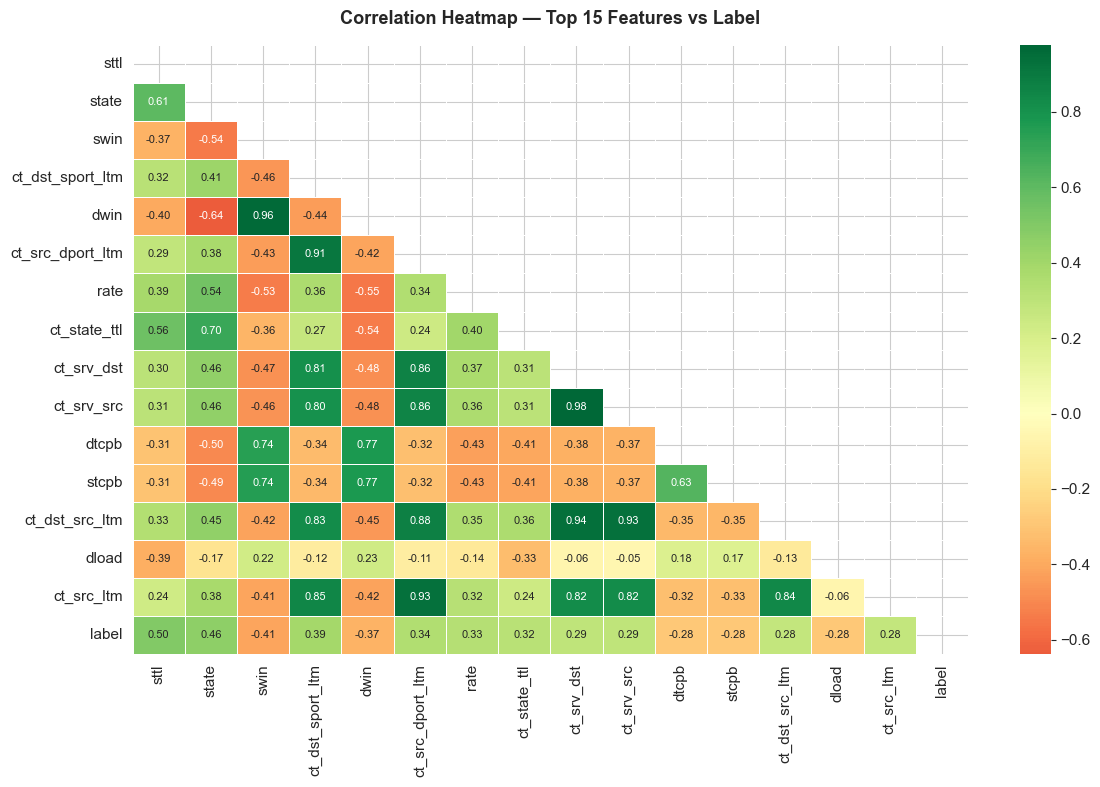

 Saved: fig2_correlation_heatmap.png

Top 5 features most correlated with attack label:
  sttl                      r = 0.5033
  state                     r = 0.4610
  swin                      r = 0.4150
  ct_dst_sport_ltm          r = 0.3938
  dwin                      r = 0.3704


In [31]:
# Show correlation of top 15 most correlated features with the label
df_corr = X_train.copy()
df_corr['label'] = y_train.values

correlations = df_corr.corr()['label'].drop('label').abs().sort_values(ascending=False)
top_features = correlations.head(15).index.tolist()

plt.figure(figsize=(12, 8))
corr_matrix = df_corr[top_features + ['label']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            annot_kws={'size': 8})
plt.title('Correlation Heatmap — Top 15 Features vs Label', 
          fontweight='bold', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('fig2_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: fig2_correlation_heatmap.png")
print(f"\nTop 5 features most correlated with attack label:")
for feat, corr in correlations.head(5).items():
    print(f"  {feat:<25} r = {corr:.4f}")


---
### 💾 5. Save Processed Data

In [33]:
X_train.to_csv("X_train.csv", index=False)
X_test.to_csv("X_test.csv", index=False)
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)
y_train_mc.to_csv("y_train_multiclass.csv", index=False)
y_test_mc.to_csv("y_test_multiclass.csv", index=False)

print(" All processed files saved:")
print("   X_train.csv              → 65,865 training records (features)")
print("   X_test.csv               → 16,467 testing records (features)")
print("   y_train.csv              → binary labels (training)")
print("   y_test.csv               → binary labels (testing)")
print("   y_train_multiclass.csv   → attack category labels (training)")
print("   y_test_multiclass.csv    → attack category labels (testing)")


 All processed files saved:
   X_train.csv              → 65,865 training records (features)
   X_test.csv               → 16,467 testing records (features)
   y_train.csv              → binary labels (training)
   y_test.csv               → binary labels (testing)
   y_train_multiclass.csv   → attack category labels (training)
   y_test_multiclass.csv    → attack category labels (testing)


---
###  Step 1 Complete — Preprocessing Summary

| Item | Value |
|---|---|
| Dataset | UNSW-NB15 |
| Total records | 82,332 |
| Features after preprocessing | 42 |
| Training records | 65,865 (80%) |
| Testing records | 16,467 (20%) |
| Missing values | 0 |
| Class balance | 55.1% Attack / 44.9% Normal |
| Encoding | LabelEncoder on proto, service, state |
| Normalization | StandardScaler on all numeric features |

---

